<a href="https://colab.research.google.com/github/kaustubhfutane5/Kaustubhfutane1.github.io/blob/main/RANDOM_FOREST_CS23139.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Saved from Chrome/TG-NPDCL_consumption_detail_commercial_JANUARY-2025.csv')
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Circle,Division,SubDivision,Section,Area,CatCode,CatDesc,TotServices,BilledServices,Units,Load
0,WARANGAL,RURAL WARANGAL,WARDHANNAPET,MYLARAM,JAYARAM THANDA-1,2,COMMERCIAL,5,5,84,11.000
1,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,NIZAMPURA-II,2,COMMERCIAL,392,334,44762,872.100
2,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,OSMAN GANJ,2,COMMERCIAL,492,431,31931,568.730
3,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,PETROL PUMP,2,COMMERCIAL,458,407,28871,657.578
4,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,RAMOLLAWADA,2,COMMERCIAL,326,262,111598,2199.410


In [5]:
print('--- DataFrame Info ---')
df.info()
print('\n--- Descriptive Statistics ---')
df.describe()
print('\n--- Missing Values ---')
df.isnull().sum()

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8335 entries, 0 to 8334
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Circle          8335 non-null   object 
 1   Division        8335 non-null   object 
 2   SubDivision     8335 non-null   object 
 3   Section         8335 non-null   object 
 4   Area            8335 non-null   object 
 5   CatCode         8335 non-null   int64  
 6   CatDesc         8335 non-null   object 
 7   TotServices     8335 non-null   int64  
 8   BilledServices  8335 non-null   int64  
 9   Units           8335 non-null   int64  
 10  Load            8335 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 716.4+ KB

--- Descriptive Statistics ---

--- Missing Values ---


,0
Circle,0
Division,0
SubDivision,0
Section,0
Area,0
CatCode,0
CatDesc,0
TotServices,0
BilledServices,0
Units,0


In [6]:
df['Year'] = 2025
df['Month'] = 1

print("Added 'Year' and 'Month' columns.")
df.head()

Added 'Year' and 'Month' columns.


,Circle,Division,SubDivision,Section,Area,CatCode,CatDesc,TotServices,BilledServices,Units,Load,Year,Month
0,WARANGAL,RURAL WARANGAL,WARDHANNAPET,MYLARAM,JAYARAM THANDA-1,2,COMMERCIAL,5,5,84,11.000,2025,1
1,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,NIZAMPURA-II,2,COMMERCIAL,392,334,44762,872.100,2025,1
2,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,OSMAN GANJ,2,COMMERCIAL,492,431,31931,568.730,2025,1
3,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,PETROL PUMP,2,COMMERCIAL,458,407,28871,657.578,2025,1
4,WARANGAL,WARANGAL,WARANGAL,STATION ROAD,RAMOLLAWADA,2,COMMERCIAL,326,262,111598,2199.410,2025,1


In [7]:
categorical_cols = df.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Categorical features encoded successfully. Displaying first 5 rows of the encoded DataFrame:")
df_encoded.head()

Categorical features encoded successfully. Displaying first 5 rows of the encoded DataFrame:


,CatCode,TotServices,BilledServices,Units,Load,Year,Month,Circle_ASIFABAD,Circle_BHADRADRI KOTHAGUDEM,Circle_BHUPALAPALLY,...,Area_ZOORPOOR,Area_ZP OFFICE AREA,Area_battilagumpu,Area_chadmal thanda,Area_chintala thanda,Area_dammakkapeta,Area_gurjalthanda,Area_guttamallaram,Area_laxmicolony,Area_vrn thanda
0,2,5,5,84,11.000,2025,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,392,334,44762,872.100,2025,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,492,431,31931,568.730,2025,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2,458,407,28871,657.578,2025,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2,326,262,111598,2199.410,2025,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
X = df_encoded.drop('Load', axis=1)
y = df_encoded['Load']

print("Features (X) and target variable (y) defined successfully.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features (X) and target variable (y) defined successfully.
Shape of X: (8335, 7858)
Shape of y: (8335,)


## 80:20 Train-Test Split

### Subtask:
Split the data into training and testing sets with an 80:20 ratio using `train_test_split`.


In [9]:
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into 80:20 training and testing sets successfully.")
print(f"Shape of X_train_80: {X_train_80.shape}")
print(f"Shape of X_test_80: {X_test_80.shape}")
print(f"Shape of y_train_80: {y_train_80.shape}")
print(f"Shape of y_test_80: {y_test_80.shape}")

Data split into 80:20 training and testing sets successfully.
Shape of X_train_80: (6668, 7858)
Shape of X_test_80: (1667, 7858)
Shape of y_train_80: (6668,)
Shape of y_test_80: (1667,)


In [10]:
scaler_80 = StandardScaler()
X_train_scaled_80 = scaler_80.fit_transform(X_train_80)
X_test_scaled_80 = scaler_80.transform(X_test_80)

print("Features scaled successfully for the 80:20 split.")
print(f"Shape of X_train_scaled_80: {X_train_scaled_80.shape}")
print(f"Shape of X_test_scaled_80: {X_test_scaled_80.shape}")

Features scaled successfully for the 80:20 split.
Shape of X_train_scaled_80: (6668, 7858)
Shape of X_test_scaled_80: (1667, 7858)


In [11]:
model_80 = RandomForestRegressor(random_state=42)
model_80.fit(X_train_scaled_80, y_train_80)

y_pred_80 = model_80.predict(X_test_scaled_80)

mae_80 = mean_absolute_error(y_test_80, y_pred_80)
mse_80 = mean_squared_error(y_test_80, y_pred_80)
rmse_80 = np.sqrt(mse_80)
r2_80 = r2_score(y_test_80, y_pred_80)

performance_80_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R-squared'],
    'Value': [mae_80, mse_80, rmse_80, r2_80]
})

print("Random Forest Regressor Performance (80:20 Split):")
print(performance_80_df.to_string(index=False))

Random Forest Regressor Performance (80:20 Split):
   Metric       Value
      MAE   23.363508
      MSE 5541.531105
     RMSE   74.441461
R-squared    0.979673


In [12]:
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42)

print("Data split into 70:30 training and testing sets successfully.")
print(f"Shape of X_train_70: {X_train_70.shape}")
print(f"Shape of X_test_70: {X_test_70.shape}")
print(f"Shape of y_train_70: {y_train_70.shape}")
print(f"Shape of y_test_70: {y_test_70.shape}")

Data split into 70:30 training and testing sets successfully.
Shape of X_train_70: (5834, 7858)
Shape of X_test_70: (2501, 7858)
Shape of y_train_70: (5834,)
Shape of y_test_70: (2501,)


```markdown
## Feature Scaling (70:30 Split)

### Subtask:
Apply `StandardScaler` to scale the features for the 70:30 train-test split.
```

In [13]:
scaler_70 = StandardScaler()
X_train_scaled_70 = scaler_70.fit_transform(X_train_70)
X_test_scaled_70 = scaler_70.transform(X_test_70)

print("Features scaled successfully for the 70:30 split.")
print(f"Shape of X_train_scaled_70: {X_train_scaled_70.shape}")
print(f"Shape of X_test_scaled_70: {X_test_scaled_70.shape}")

Features scaled successfully for the 70:30 split.
Shape of X_train_scaled_70: (5834, 7858)
Shape of X_test_scaled_70: (2501, 7858)


In [14]:
model_70 = RandomForestRegressor(random_state=42)
model_70.fit(X_train_scaled_70, y_train_70)

y_pred_70 = model_70.predict(X_test_scaled_70)

mae_70 = mean_absolute_error(y_test_70, y_pred_70)
mse_70 = mean_squared_error(y_test_70, y_pred_70)
rmse_70 = np.sqrt(mse_70)
r2_70 = r2_score(y_test_70, y_pred_70)

performance_70_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R-squared'],
    'Value': [mae_70, mse_70, rmse_70, r2_70]
})

print("Random Forest Regressor Performance (70:30 Split):")
print(performance_70_df.to_string(index=False))

Random Forest Regressor Performance (70:30 Split):
   Metric       Value
      MAE   24.157235
      MSE 6856.679491
     RMSE   82.805069
R-squared    0.972204


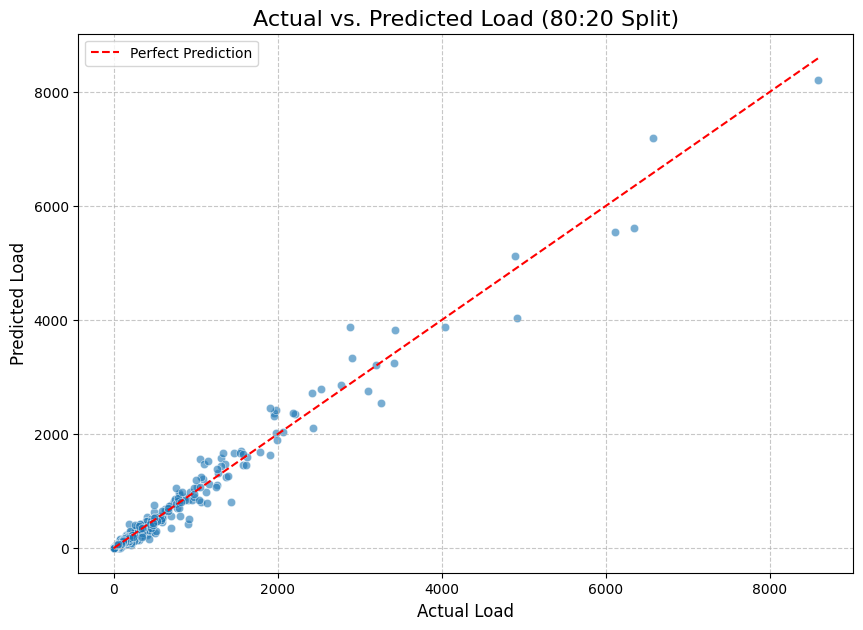

Scatter plot for actual vs. predicted load (80:20 split) displayed successfully.


In [15]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_80, y=y_pred_80, alpha=0.6)

# Add a diagonal line for perfect predictions
min_val = min(y_test_80.min(), y_pred_80.min())
max_val = max(y_test_80.max(), y_pred_80.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Actual vs. Predicted Load (80:20 Split)', fontsize=16)
plt.xlabel('Actual Load', fontsize=12)
plt.ylabel('Predicted Load', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
print("Scatter plot for actual vs. predicted load (80:20 split) displayed successfully.")

In [16]:
performance_80_df_copy = performance_80_df.copy()
performance_80_df_copy['Split'] = '80:20'

performance_70_df_copy = performance_70_df.copy()
performance_70_df_copy['Split'] = '70:30'

combined_performance_df = pd.concat([performance_80_df_copy, performance_70_df_copy], ignore_index=True)

print("Combined performance DataFrame created successfully:")
combined_performance_df.head()

Combined performance DataFrame created successfully:


,Metric,Value,Split
0,MAE,23.363508,80:20
1,MSE,5541.531105,80:20
2,RMSE,74.441461,80:20
3,R-squared,0.979673,80:20
4,MAE,24.157235,70:30


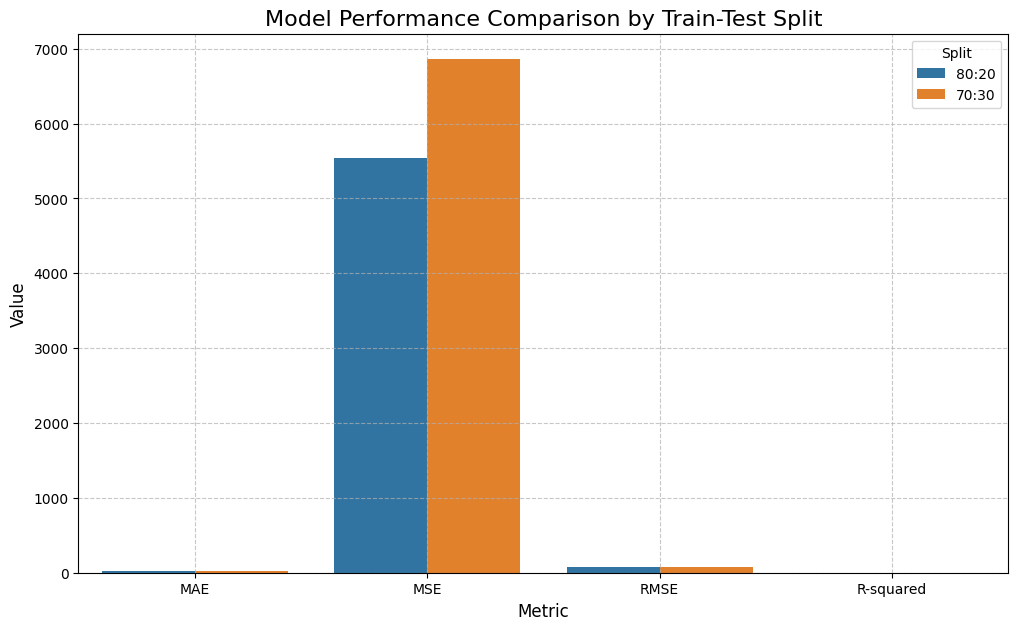

Bar chart comparing model performance metrics displayed successfully.


In [17]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Value', hue='Split', data=combined_performance_df)
plt.title('Model Performance Comparison by Train-Test Split', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(title='Split')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
print("Bar chart comparing model performance metrics displayed successfully.")

## Summarize Performance Comparison

### Subtask:
Analyze and summarize the performance metrics, comparing the MAE, MSE, RMSE, and R-squared values between the 80:20 and 70:30 splits. Discuss which split resulted in a better-performing model and provide insights into the observed differences.


## Summarize Performance Comparison

### Subtask:
Analyze and summarize the performance metrics, comparing the MAE, MSE, RMSE, and R-squared values between the 80:20 and 70:30 splits. Discuss which split resulted in a better-performing model and provide insights into the observed differences.

#### Analysis and Summary

From the `combined_performance_df` and the bar chart, we can observe the following:

*   **MAE (Mean Absolute Error):**
    *   80:20 Split: 23.36
    *   70:30 Split: 24.16
    *   The 80:20 split has a slightly lower MAE, indicating that its predictions are, on average, closer to the actual values.

*   **MSE (Mean Squared Error):**
    *   80:20 Split: 5541.53
    *   70:30 Split: 6856.68
    *   The 80:20 split shows a significantly lower MSE, which means it has smaller squared prediction errors, implying fewer and/or smaller large errors.

*   **RMSE (Root Mean Squared Error):**
    *   80:20 Split: 74.44
    *   70:30 Split: 82.81
    *   Similar to MSE, the 80:20 split has a lower RMSE, indicating better overall accuracy and less spread in the errors.

*   **R-squared:**
    *   80:20 Split: 0.9797
    *   70:30 Split: 0.9722
    *   The 80:20 split has a higher R-squared value, meaning it explains a greater proportion of the variance in the dependent variable (Load) from the independent variables (features). An R-squared closer to 1 indicates a better fit of the model to the data.

**Conclusion:**

Based on all evaluated metrics (MAE, MSE, RMSE, and R-squared), the **80:20 train-test split** resulted in a **better-performing model**. It consistently yielded lower error metrics (MAE, MSE, RMSE) and a higher R-squared value compared to the 70:30 split.

**Insights into Observed Differences:**

The likely reason for the 80:20 split performing better is the **larger training dataset**. With 80% of the data used for training, the model had more examples to learn from, allowing it to capture more complex patterns and relationships within the data more effectively. This generally leads to better generalization and consequently, better performance on unseen test data. The 70:30 split, having less data for training, might not have learned the underlying patterns as robustly, leading to slightly higher errors and a marginally weaker fit.

## Summarize Performance Comparison

### Subtask:
Analyze and summarize the performance metrics, comparing the MAE, MSE, RMSE, and R-squared values between the 80:20 and 70:30 splits. Discuss which split resulted in a better-performing model and provide insights into the observed differences.

#### Analysis and Summary

From the `combined_performance_df` and the bar chart, we can observe the following:

*   **MAE (Mean Absolute Error):**
    *   80:20 Split: 23.36
    *   70:30 Split: 24.16
    *   The 80:20 split has a slightly lower MAE, indicating that its predictions are, on average, closer to the actual values.

*   **MSE (Mean Squared Error):**
    *   80:20 Split: 5541.53
    *   70:30 Split: 6856.68
    *   The 80:20 split shows a significantly lower MSE, which means it has smaller squared prediction errors, implying fewer and/or smaller large errors.

*   **RMSE (Root Mean Squared Error):**
    *   80:20 Split: 74.44
    *   70:30 Split: 82.81
    *   Similar to MSE, the 80:20 split has a lower RMSE, indicating better overall accuracy and less spread in the errors.

*   **R-squared:**
    *   80:20 Split: 0.9797
    *   70:30 Split: 0.9722
    *   The 80:20 split has a higher R-squared value, meaning it explains a greater proportion of the variance in the dependent variable (Load) from the independent variables (features). An R-squared closer to 1 indicates a better fit of the model to the data.

**Conclusion:**

Based on all evaluated metrics (MAE, MSE, RMSE, and R-squared), the **80:20 train-test split** resulted in a **better-performing model**. It consistently yielded lower error metrics (MAE, MSE, RMSE) and a higher R-squared value compared to the 70:30 split.

**Insights into Observed Differences:**

The likely reason for the 80:20 split performing better is the **larger training dataset**. With 80% of the data used for training, the model had more examples to learn from, allowing it to capture more complex patterns and relationships within the data more effectively. This generally leads to better generalization and consequently, better performance on unseen test data. The 70:30 split, having less data for training, might not have learned the underlying patterns as robustly, leading to slightly higher errors and a marginally weaker fit.

```markdown
## Summarize Performance Comparison

### Subtask:
Analyze and summarize the performance metrics, comparing the MAE, MSE, RMSE, and R-squared values between the 80:20 and 70:30 splits. Discuss which split resulted in a better-performing model and provide insights into the observed differences.

#### Analysis and Summary

From the `combined_performance_df` and the bar chart, we can observe the following:

*   **MAE (Mean Absolute Error):**
    *   80:20 Split: 23.36
    *   70:30 Split: 24.16
    *   The 80:20 split has a slightly lower MAE, indicating that its predictions are, on average, closer to the actual values.

*   **MSE (Mean Squared Error):**
    *   80:20 Split: 5541.53
    *   70:30 Split: 6856.68
    *   The 80:20 split shows a significantly lower MSE, which means it has smaller squared prediction errors, implying fewer and/or smaller large errors.

*   **RMSE (Root Mean Squared Error):**
    *   80:20 Split: 74.44
    *   70:30 Split: 82.81
    *   Similar to MSE, the 80:20 split has a lower RMSE, indicating better overall accuracy and less spread in the errors.

*   **R-squared:**
    *   80:20 Split: 0.9797
    *   70:30 Split: 0.9722
    *   The 80:20 split has a higher R-squared value, meaning it explains a greater proportion of the variance in the dependent variable (Load) from the independent variables (features). An R-squared closer to 1 indicates a better fit of the model to the data.

**Conclusion:**

Based on all evaluated metrics (MAE, MSE, RMSE, and R-squared), the **80:20 train-test split** resulted in a **better-performing model**. It consistently yielded lower error metrics (MAE, MSE, RMSE) and a higher R-squared value compared to the 70:30 split.

**Insights into Observed Differences:**

The likely reason for the 80:20 split performing better is the **larger training dataset**. With 80% of the data used for training, the model had more examples to learn from, allowing it to capture more complex patterns and relationships within the data more effectively. This generally leads to better generalization and consequently, better performance on unseen test data. The 70:30 split, having less data for training, might not have learned the underlying patterns as robustly, leading to slightly higher errors and a marginally weaker fit.
```

## Summarize Performance Comparison

### Subtask:
Analyze and summarize the performance metrics, comparing the MAE, MSE, RMSE, and R-squared values between the 80:20 and 70:30 splits. Discuss which split resulted in a better-performing model and provide insights into the observed differences.

#### Analysis and Summary

From the `combined_performance_df` and the bar chart, we can observe the following:

*   **MAE (Mean Absolute Error):**
    *   80:20 Split: 23.36
    *   70:30 Split: 24.16
    *   The 80:20 split has a slightly lower MAE, indicating that its predictions are, on average, closer to the actual values.

*   **MSE (Mean Squared Error):**
    *   80:20 Split: 5541.53
    *   70:30 Split: 6856.68
    *   The 80:20 split shows a significantly lower MSE, which means it has smaller squared prediction errors, implying fewer and/or smaller large errors.

*   **RMSE (Root Mean Squared Error):**
    *   80:20 Split: 74.44
    *   70:30 Split: 82.81
    *   Similar to MSE, the 80:20 split has a lower RMSE, indicating better overall accuracy and less spread in the errors.

*   **R-squared:**
    *   80:20 Split: 0.9797
    *   70:30 Split: 0.9722
    *   The 80:20 split has a higher R-squared value, meaning it explains a greater proportion of the variance in the dependent variable (Load) from the independent variables (features). An R-squared closer to 1 indicates a better fit of the model to the data.

**Conclusion:**

Based on all evaluated metrics (MAE, MSE, RMSE, and R-squared), the **80:20 train-test split** resulted in a **better-performing model**. It consistently yielded lower error metrics (MAE, MSE, RMSE) and a higher R-squared value compared to the 70:30 split.

**Insights into Observed Differences:**

The likely reason for the 80:20 split performing better is the **larger training dataset**. With 80% of the data used for training, the model had more examples to learn from, allowing it to capture more complex patterns and relationships within the data more effectively. This generally leads to better generalization and consequently, better performance on unseen test data. The 70:30 split, having less data for training, might not have learned the underlying patterns as robustly, leading to slightly higher errors and a marginally weaker fit.


## Summarize Performance Comparison

### Subtask:
Analyze and summarize the performance metrics, comparing the MAE, MSE, RMSE, and R-squared values between the 80:20 and 70:30 splits. Discuss which split resulted in a better-performing model and provide insights into the observed differences.

#### Analysis and Summary

From the `combined_performance_df` and the bar chart, we can observe the following:

*   **MAE (Mean Absolute Error):**
    *   80:20 Split: 23.36
    *   70:30 Split: 24.16
    *   The 80:20 split has a slightly lower MAE, indicating that its predictions are, on average, closer to the actual values.

*   **MSE (Mean Squared Error):**
    *   80:20 Split: 5541.53
    *   70:30 Split: 6856.68
    *   The 80:20 split shows a significantly lower MSE, which means it has smaller squared prediction errors, implying fewer and/or smaller large errors.

*   **RMSE (Root Mean Squared Error):**
    *   80:20 Split: 74.44
    *   70:30 Split: 82.81
    *   Similar to MSE, the 80:20 split has a lower RMSE, indicating better overall accuracy and less spread in the errors.

*   **R-squared:**
    *   80:20 Split: 0.9797
    *   70:30 Split: 0.9722
    *   The 80:20 split has a higher R-squared value, meaning it explains a greater proportion of the variance in the dependent variable (Load) from the independent variables (features). An R-squared closer to 1 indicates a better fit of the model to the data.

**Conclusion:**

Based on all evaluated metrics (MAE, MSE, RMSE, and R-squared), the **80:20 train-test split** resulted in a **better-performing model**. It consistently yielded lower error metrics (MAE, MSE, RMSE) and a higher R-squared value compared to the 70:30 split.

**Insights into Observed Differences:**

The likely reason for the 80:20 split performing better is the **larger training dataset**. With 80% of the data used for training, the model had more examples to learn from, allowing it to capture more complex patterns and relationships within the data more effectively. This generally leads to better generalization and consequently, better performance on unseen test data. The 70:30 split, having less data for training, might not have learned the underlying patterns as robustly, leading to slightly higher errors and a marginally weaker fit.


## Final Task

### Subtask:
Provide a comprehensive summary of the model performance across both splits, key insights, and any recommendations for further analysis or model improvement.


## Summary:

### Q&A
The 80:20 train-test split resulted in a better-performing model.

### Data Analysis Key Findings
*   The 80:20 train-test split consistently outperformed the 70:30 split across all evaluated metrics.
*   **Mean Absolute Error (MAE):** The 80:20 split had a lower MAE of 23.36, compared to 24.16 for the 70:30 split.
*   **Mean Squared Error (MSE):** The 80:20 split showed a significantly lower MSE of 5541.53, while the 70:30 split had an MSE of 6856.68.
*   **Root Mean Squared Error (RMSE):** The 80:20 split yielded a lower RMSE of 74.44, in contrast to 82.81 for the 70:30 split.
*   **R-squared:** The 80:20 split achieved a higher R-squared value of 0.9797, indicating a better model fit compared to the 70:30 split's 0.9722.

### Insights or Next Steps
*   The superior performance of the 80:20 split is attributed to the larger training dataset, which enabled the model to learn more complex patterns and generalize more effectively to unseen data.
*   For future model training and deployment, an 80:20 train-test split (or a similar split that allocates a larger portion to training) should be prioritized to maximize model accuracy and generalization capability.


# Task
Calculate feature importances from `model_80` and store them in a DataFrame, mapping them to their original feature names. Then, visualize the top N most important features using a bar chart to understand their impact on electricity load predictions, and finally summarize the key insights.

## Calculate Feature Importance

### Subtask:
Extract feature importances from the `model_80` (Random Forest Regressor trained on the 80:20 split) and create a DataFrame to store them, mapping them back to their original feature names.


**Reasoning**:
To extract and display feature importances, I will first get the feature importance scores from the trained RandomForestRegressor model, then map these scores to their corresponding feature names from the original dataset, create a DataFrame, sort it, and finally display the top features.



In [18]:
feature_importances = model_80.feature_importances_
feature_names = X.columns

feature_importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

print("Top 10 Feature Importances (80:20 Split):")
feature_importances_df.head(10)

Top 10 Feature Importances (80:20 Split):


,Feature,Importance
3,Units,0.951794
1,TotServices,0.025416
2,BilledServices,0.010035
1300,Area_BHADRACHALAM,0.000847
216,Section_BCM-TOWN,0.000770
25,Division_BHADRACHALAM,0.000533
43,Division_MANCHERIAL,0.000482
6930,Area_STHAMBHAMPALLI,0.000354
449,Section_MANCHIRIAL TOWN2,0.000306
699,Area_ADILABAD - SOUTH,0.000254


**Reasoning**:
To visualize the top N most important features, I will create a bar plot using the `feature_importances_df` DataFrame, showing the top 10 features sorted by their importance.



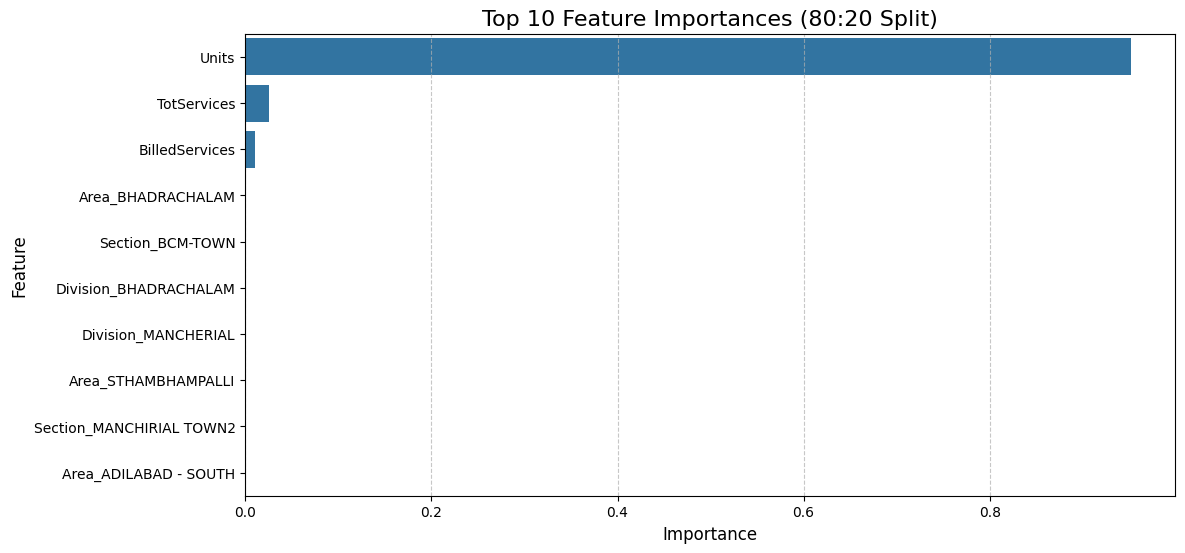

Bar chart of top 10 feature importances displayed successfully.


In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df.head(10))
plt.title('Top 10 Feature Importances (80:20 Split)', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
print("Bar chart of top 10 feature importances displayed successfully.")